In [4]:
import pandas as pd 
from matplotlib import pyplot as plt 
import seaborn as sns 

### Load Data

In [6]:
df = pd.read_csv("ad_spend.csv")
df.head(2)

,Ad Spend ($),Season,Revenue ($)
0,463,Monsoon,440
1,158,Winter,297


### Exploratory Data Analysis: EDA

In [9]:
df.shape

(200, 3)

In [13]:
mean_group = df.groupby("Season")[["Ad Spend ($)" , "Revenue ($)"]].mean()
print(mean_group)

         Ad Spend ($)  Revenue ($)
Season                            
Monsoon    517.643836   423.150685
Summer     573.836066   689.360656
Winter     552.560606   826.530303


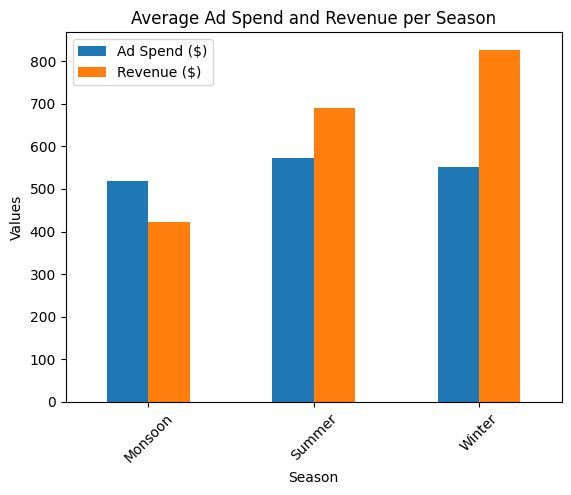

In [17]:
plot = mean_group.plot(kind="bar")
plot.set_title('Average Ad Spend and Revenue per Season')
plot.set_xlabel('Season')
plot.set_ylabel('Values')

plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

### Feature Engineering: Encode the Categorical Data Using One Hot Encoding

In [24]:
df_encoded = pd.get_dummies(df , columns=["Season"] , drop_first=True)
df_encoded.head(3)

,Ad Spend ($),Revenue ($),Season_Summer,Season_Winter
0,463,440,False,False
1,158,297,False,True
2,328,214,False,False


### using simple linear regression model to predict 

In [47]:
from sklearn.model_selection import train_test_split
X = df_encoded.drop("Revenue ($)" , axis=1)
y = df_encoded["Revenue ($)"]

x_train , x_test , y_train , y_test = train_test_split(X , y , test_size=0.25 , random_state=42)


In [43]:
from sklearn.linear_model import LinearRegression 
model = LinearRegression()
model.fit(x_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### predict the score 

In [44]:
model.score(x_train , y_train)

0.878300539370504

### Train a Decision Tree Regressor


In [45]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(x_train , y_train)
model.score(x_train , y_train)

0.9987546146023965

### Train a Gradient Boosting Model

In [77]:
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor(n_estimators=25)
model.fit(x_train , y_train)
model.score(x_train , y_train)

0.9259265177858327

In [78]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(x_test)

mean_squared_error(y_test, y_pred)

16656.213756227306

In [79]:
df_eval = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
df_eval.head(3)

,Actual,Predicted
95,903,938.775678
15,1047,867.341229
30,1026,863.055642


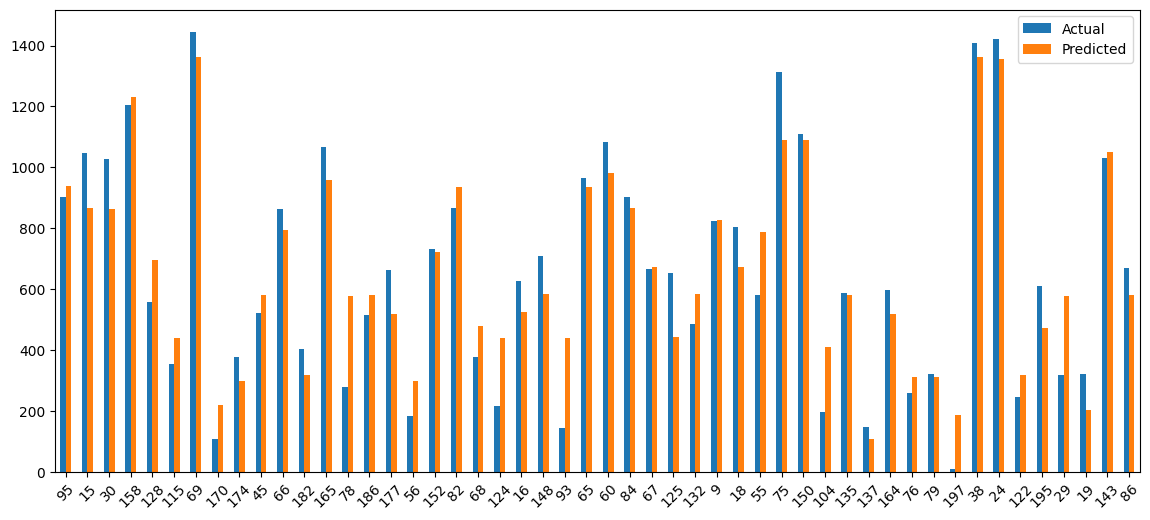

In [80]:
df_eval.plot(kind="bar" , figsize=(14, 6))
plt.xticks(rotation=45)
plt.show()